# Regressão


Este notebook serve para testar vários dataset para realizar a regressão

importar bibliotecas e matplotlib

In [113]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
from scipy.stats import t as t_dist
from sklearn.preprocessing import StandardScaler
import missingno as msno

# Configuração do matplotlib
warnings.filterwarnings('default')
plt.switch_backend('Agg')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print('Bibliotecas carregadas com sucesso!')


Bibliotecas carregadas com sucesso!


# Carregar dos dados

In [114]:
df = pd.read_csv('processed_lisboa_porto_air_quality.csv', sep=';')

# 1º Modelo regressão

In [115]:
df.columns = df.columns.str.lower()

df_clean = df.dropna(subset=['no2','co','datetime','nox','temperature_c','c6h6','humidity_percent','air_quality_good'])

print(f'Dataset: {df_clean.shape[0]} observações × {df_clean.shape[1]} variáveis')

Dataset: 6941 observações × 20 variáveis


# Selecionar variaveis numéricas para análise

In [116]:
df_clean['datetime'] = pd.to_datetime(df_clean['datetime'], format='%d/%m/%y %H:%M')

# criar variáveis temporais
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['day'] = df_clean['datetime'].dt.day
df_clean['month'] = df_clean['datetime'].dt.month

y = df_clean['no2']

features = [
    'co','day', 'month', 'hour','nox','air_quality_good','temperature_c','c6h6','humidity_percent'
]

X = df_clean[features]


print("Shape:", X.shape)


print(f"Features: {X.shape[1]}")
## Verificar NaNs
print("NaNs antes:")
print(X.isnull().sum())
print("df_cleanheader:")
df.head()


Shape: (6941, 9)
Features: 9
NaNs antes:
co                  0
day                 0
month               0
hour                0
nox                 0
air_quality_good    0
temperature_c       0
c6h6                0
humidity_percent    0
dtype: int64
df_cleanheader:


,city,datetime,co,no2,o3,pm10,pm2.5,so2,temperature_c,humidity_percent,pressure_hpa,wind_speed_kmh,wind_direction_deg,precipitation_mm,c6h6,nmhc,nox,air_quality_good,year,month
0,Lisboa,05/09/25 01:00,0.96,25.20,84.09,11.82,9.12,6.75,18.9,82.0,1018.5,16.2,357.0,0.0,NaN,NaN,NaN,True,2025,9
1,Lisboa,05/09/25 02:00,0.75,26.40,86.20,13.24,8.87,5.11,18.8,80.0,1018.3,15.5,356.0,0.0,NaN,NaN,NaN,True,2025,9
2,Lisboa,05/09/25 03:00,0.87,25.16,74.41,15.18,10.84,5.76,18.6,79.0,1017.4,11.5,2.0,0.0,NaN,NaN,NaN,True,2025,9
3,Lisboa,05/09/25 04:00,0.51,13.59,68.57,17.48,13.14,5.03,18.3,77.0,1017.2,11.3,351.0,0.0,NaN,NaN,NaN,True,2025,9
4,Lisboa,05/09/25 05:00,0.61,15.89,78.79,14.70,13.68,6.20,18.6,72.0,1016.8,9.4,356.0,0.0,NaN,NaN,NaN,True,2025,9


# 2º  modelo regressão

In [117]:
df.columns = df.columns.str.lower()

df_clean2 = df.dropna(subset=['no2','co','pm10', 'pm2.5', 'o3', 'so2','temperature_c', 'humidity_percent','wind_speed_kmh', 'pressure_hpa','precipitation_mm', 'datetime'])

print(f'Dataset: {df_clean2.shape[0]} observações × {df_clean2.shape[1]} variáveis')

Dataset: 1442 observações × 20 variáveis


# Selecionar variaveis numéricas para análise

In [118]:
df_clean2['datetime'] = pd.to_datetime(df_clean2['datetime'], format='%d/%m/%y %H:%M')

# criar variáveis temporais
df_clean2['hour'] = df_clean2['datetime'].dt.hour
df_clean2['day'] = df_clean2['datetime'].dt.day
df_clean2['month'] = df_clean2['datetime'].dt.month

y1 = df_clean2['no2']

features2 = [
    'pm10', 'pm2.5', 'o3', 'so2',
    'temperature_c', 'humidity_percent',
    'wind_speed_kmh', 'pressure_hpa',
    'precipitation_mm',
    'day', 'month', 'hour','co'
]

X1 = df_clean2[features2]
    
# 9157 observações
print("Shape:", X1.shape)

#12 features
print(f"Features: {X1.shape[1]}")
## Verificar NaNs
print("NaNs antes:")
print(X1.isnull().sum())
df_clean2.head()


Shape: (1442, 13)
Features: 13
NaNs antes:
pm10                0
pm2.5               0
o3                  0
so2                 0
temperature_c       0
humidity_percent    0
wind_speed_kmh      0
pressure_hpa        0
precipitation_mm    0
day                 0
month               0
hour                0
co                  0
dtype: int64


,city,datetime,co,no2,o3,pm10,pm2.5,so2,temperature_c,humidity_percent,pressure_hpa,wind_speed_kmh,wind_direction_deg,precipitation_mm,c6h6,nmhc,nox,air_quality_good,year,month,hour,day
0,Lisboa,2025-09-05 01:00:00,0.96,25.20,84.09,11.82,9.12,6.75,18.9,82.0,1018.5,16.2,357.0,0.0,NaN,NaN,NaN,True,2025,9,1,5
1,Lisboa,2025-09-05 02:00:00,0.75,26.40,86.20,13.24,8.87,5.11,18.8,80.0,1018.3,15.5,356.0,0.0,NaN,NaN,NaN,True,2025,9,2,5
2,Lisboa,2025-09-05 03:00:00,0.87,25.16,74.41,15.18,10.84,5.76,18.6,79.0,1017.4,11.5,2.0,0.0,NaN,NaN,NaN,True,2025,9,3,5
3,Lisboa,2025-09-05 04:00:00,0.51,13.59,68.57,17.48,13.14,5.03,18.3,77.0,1017.2,11.3,351.0,0.0,NaN,NaN,NaN,True,2025,9,4,5
4,Lisboa,2025-09-05 05:00:00,0.61,15.89,78.79,14.70,13.68,6.20,18.6,72.0,1016.8,9.4,356.0,0.0,NaN,NaN,NaN,True,2025,9,5,5


# Criar pré-processamentos


# Modelo 1

In [119]:
# Dividir os dados em treino e teste. 20% para teste, 80% para treino.


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


# ajustar escala dos dados

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# treinar modelo

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Modelo treinado")

Train: (5552, 9), Test: (1389, 9)
Modelo treinado


# Resultados 1º Modelo


In [120]:
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n Resultados:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")


 Resultados:
RMSE: 23.00
MAE: 17.24
R2: 0.75


# Treinar 2º Modelo


In [121]:
# Dividir os dados em treino e teste. 20% para teste, 80% para treino.


X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

print(f"Train: {X1_train.shape}, Test: {X1_test.shape}")


# ajustar escala dos dados

scaler1 = StandardScaler()

X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)


# treinar modelo

model1 = LinearRegression()
model1.fit(X1_train_scaled, y1_train)

print("Modelo treinado")

Train: (1153, 13), Test: (289, 13)
Modelo treinado


# Resultados 2º Modelo

In [122]:
y1_pred = model1.predict(X1_test_scaled)

rmse1 = np.sqrt(mean_squared_error(y1_test, y1_pred))
mae1 = mean_absolute_error(y1_test, y1_pred)
r21 = r2_score(y1_test, y1_pred)

print("\n Resultados:")
print(f"RMSE: {rmse1:.2f}")
print(f"MAE: {mae1:.2f}")
print(f"R2: {r21:.2f}")


 Resultados:
RMSE: 6.69
MAE: 5.09
R2: 0.72


# Guardar dados

In [123]:
import os
import pickle
import pandas as pd

# Criar pasta para guardar resultados

folder_name = "regression_results"

os.makedirs(folder_name, exist_ok=True)


# guardar métricas numéricas em CSV

metrics = pd.DataFrame({
    "model": [
        "Linear Regression 1",
        "Linear Regression 2"
    ],
    "rmse": [
        rmse,
        rmse1
    ],
    "mae": [
        mae,
        mae1
    ],
    "r2": [
        r2,
        r21
    ]
})

metrics.to_csv(
    f"{folder_name}/metrics_regression.csv",
    index=False
)

print("Métricas guardadas")

# Guardar pickles

with open(f"{folder_name}/regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open(f"{folder_name}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(f"{folder_name}/regression_model1.pkl", "wb") as f:
    pickle.dump(model1, f)

with open(f"{folder_name}/scaler1.pkl", "wb") as f:
    pickle.dump(scaler1, f)

print("Modelos e scalers guardados")

Métricas guardadas
Modelos e scalers guardados


# Visualizar os datasets

In [124]:
%matplotlib inline

/opt/anaconda3/envs/panda/lib/python3.12/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(
/opt/anaconda3/envs/panda/lib/python3.12/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(
/opt/anaconda3/envs/panda/lib/python3.12/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


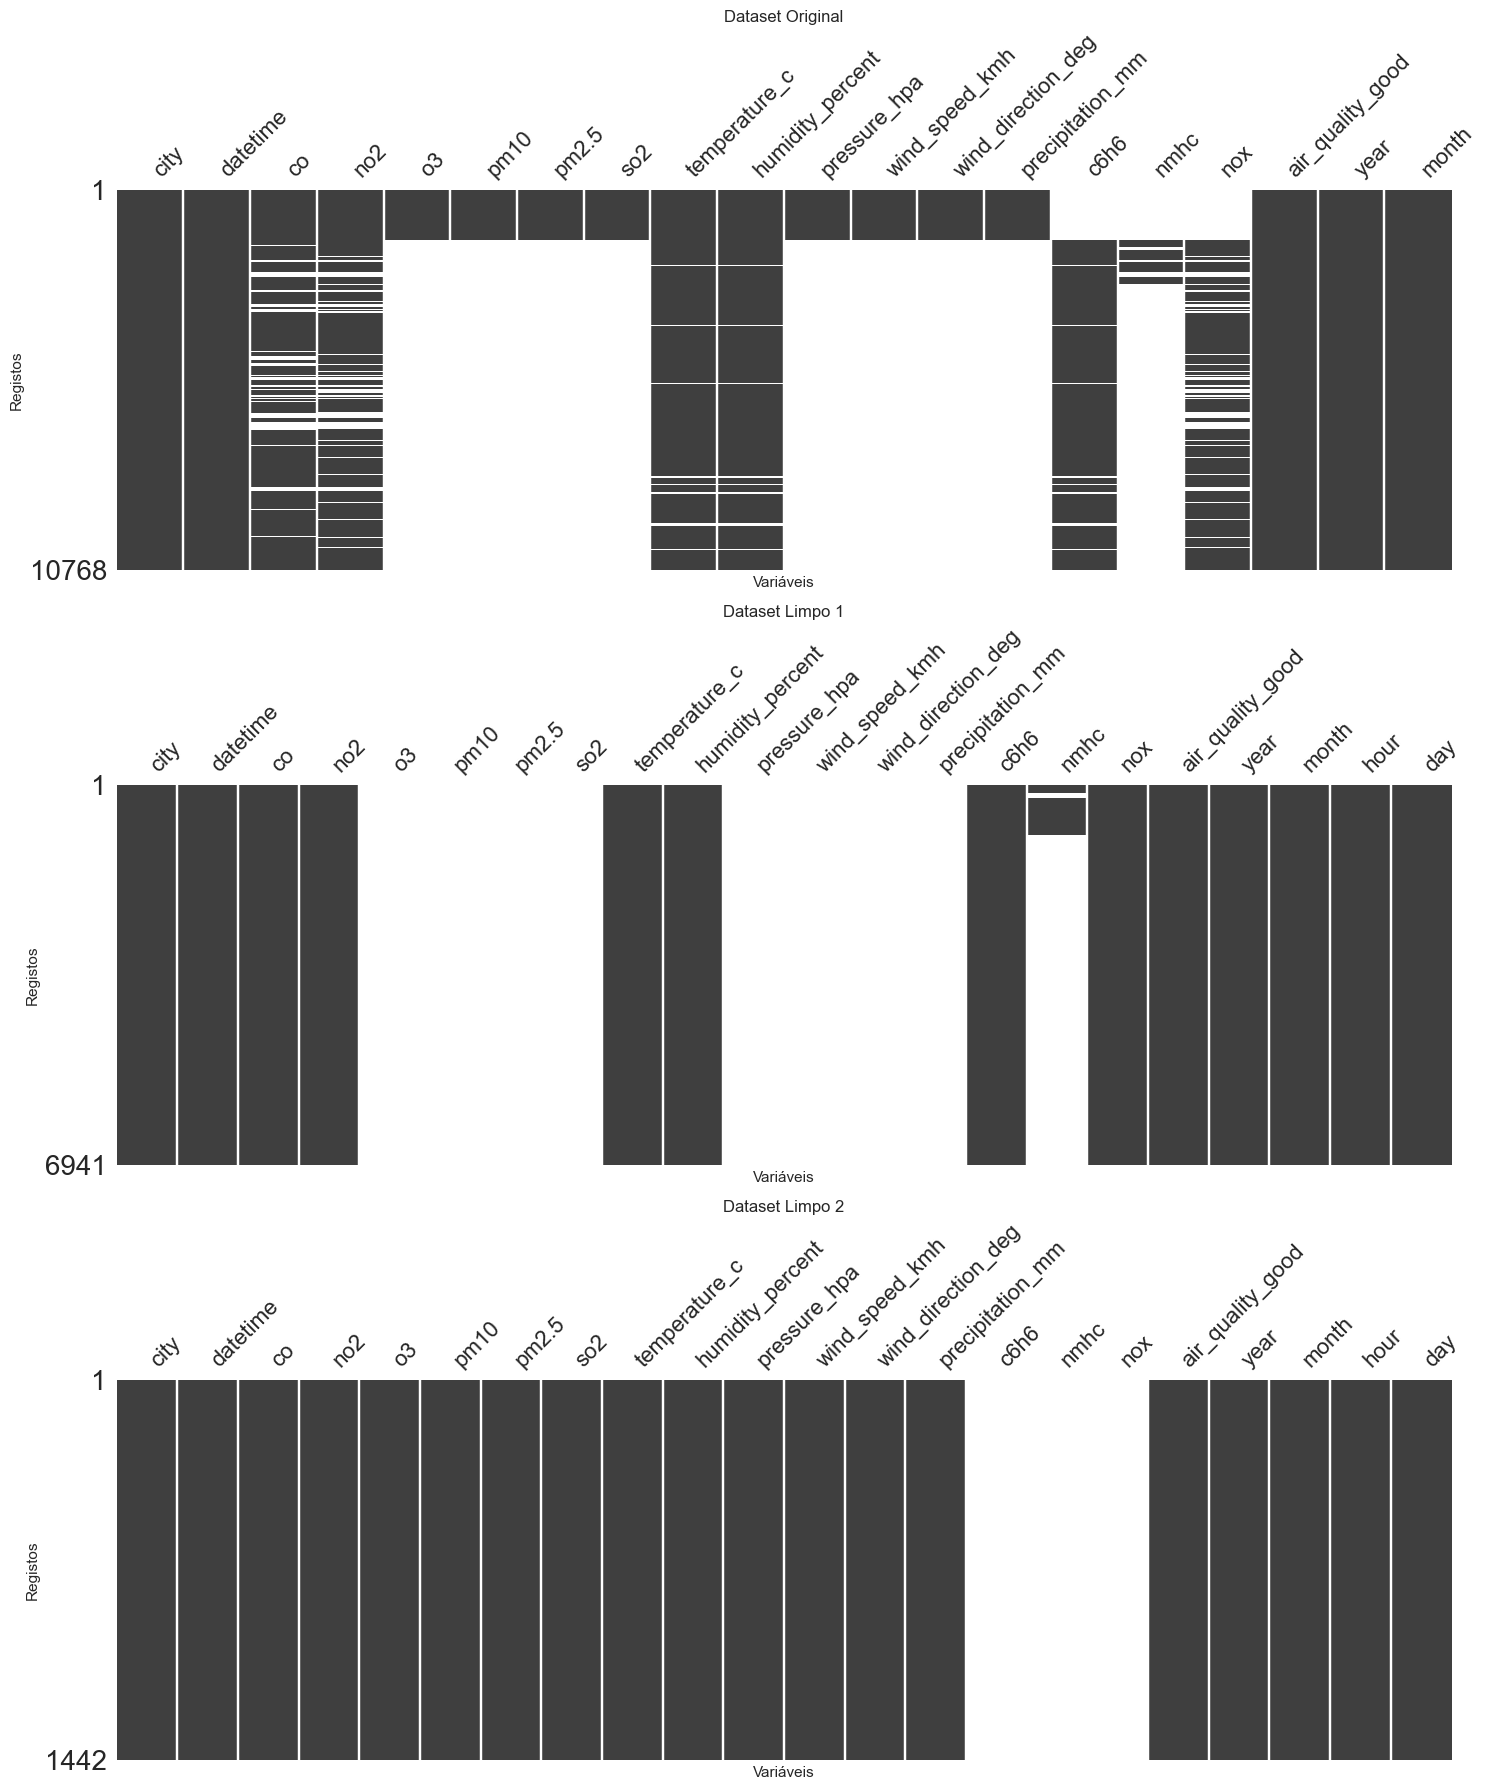

In [125]:
%matplotlib inline


fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# Gráfico 1
msno.matrix(df, ax=axes[0])
axes[0].set_title("Dataset Original")
axes[0].set_xlabel("Variáveis")
axes[0].set_ylabel("Registos")

# Gráfico 2
msno.matrix(df_clean, ax=axes[1])
axes[1].set_title("Dataset Limpo 1")
axes[1].set_xlabel("Variáveis")
axes[1].set_ylabel("Registos")

# Gráfico 3
msno.matrix(df_clean2, ax=axes[2])
axes[2].set_title("Dataset Limpo 2")
axes[2].set_xlabel("Variáveis")
axes[2].set_ylabel("Registos")

plt.tight_layout()
plt.show()